In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
from scipy.stats import geom
from scipy.optimize import minimize

In [2]:
apple = pd.read_csv(r"D:\data\aapl.us.txt")
apple.head()

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,AAPL.US,D,19840907,0,0.10122,0.10246,0.10000,0.10122,97236149,0
1,AAPL.US,D,19840910,0,0.10122,0.10153,0.09878,0.10062,75471114,0
2,AAPL.US,D,19840911,0,0.10153,0.10428,0.10153,0.10246,177965367,0
3,AAPL.US,D,19840912,0,0.10246,0.10306,0.09938,0.09938,155467926,0
4,AAPL.US,D,19840913,0,0.10490,0.10520,0.10490,0.10490,242135546,0


In [3]:
apple['<DATE>'] = pd.to_datetime(apple['<DATE>'], format="%Y%m%d")
apple.dtypes
apple.head()

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,AAPL.US,D,1984-09-07,0,0.10122,0.10246,0.10000,0.10122,97236149,0
1,AAPL.US,D,1984-09-10,0,0.10122,0.10153,0.09878,0.10062,75471114,0
2,AAPL.US,D,1984-09-11,0,0.10153,0.10428,0.10153,0.10246,177965367,0
3,AAPL.US,D,1984-09-12,0,0.10246,0.10306,0.09938,0.09938,155467926,0
4,AAPL.US,D,1984-09-13,0,0.10490,0.10520,0.10490,0.10490,242135546,0


In [4]:
apple.columns = apple.columns.str.strip().str.strip("<>").str.upper()

In [5]:
apple['DayOfWeek'] = apple['DATE'].dt.day_name()
apple.tail()

,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DayOfWeek
9479,AAPL.US,D,2022-04-18,0,163.92,166.5984,163.57,165.07,69023941,0,Monday
9480,AAPL.US,D,2022-04-19,0,165.02,167.8200,163.91,167.40,67723833,0,Tuesday
9481,AAPL.US,D,2022-04-20,0,168.76,168.8800,166.10,167.23,67929814,0,Wednesday
9482,AAPL.US,D,2022-04-21,0,168.91,171.5300,165.91,166.42,87227768,0,Thursday
9483,AAPL.US,D,2022-04-22,0,166.46,167.8699,161.50,161.79,84753396,0,Friday


In [6]:
apple['weekday'] = apple['DATE'].dt.weekday   # Mon=0 ... Sun=6
apple['week']    = apple['DATE'].dt.to_period('W-SUN')


In [7]:
apple.head()

,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DayOfWeek,weekday,week
0,AAPL.US,D,1984-09-07,0,0.10122,0.10246,0.10000,0.10122,97236149,0,Friday,4,1984-09-03/1984-09-09
1,AAPL.US,D,1984-09-10,0,0.10122,0.10153,0.09878,0.10062,75471114,0,Monday,0,1984-09-10/1984-09-16
2,AAPL.US,D,1984-09-11,0,0.10153,0.10428,0.10153,0.10246,177965367,0,Tuesday,1,1984-09-10/1984-09-16
3,AAPL.US,D,1984-09-12,0,0.10246,0.10306,0.09938,0.09938,155467926,0,Wednesday,2,1984-09-10/1984-09-16
4,AAPL.US,D,1984-09-13,0,0.10490,0.10520,0.10490,0.10490,242135546,0,Thursday,3,1984-09-10/1984-09-16


In [8]:
tue_open = (apple.loc[apple['weekday'] == 1]        # Tuesday
                 .groupby('week')['OPEN']
                 .first()
                 .rename('buy_tue_open'))

thu_open = (apple.loc[apple['weekday'] == 3]        # Thursday
                 .groupby('week')['OPEN']
                 .first()
                 .rename('sell_thu_open'))
tue_open.head()

week
1984-09-10/1984-09-16    0.10153
1984-09-17/1984-09-23    0.10918
1984-09-24/1984-09-30    0.10122
1984-10-01/1984-10-07    0.09419
1984-10-08/1984-10-14    0.09481
Freq: W-SUN, Name: buy_tue_open, dtype: float64

In [9]:
weekly = pd.concat([tue_open, thu_open], axis=1).dropna()  
weekly['net%'] = ((weekly['sell_thu_open'] / weekly['buy_tue_open']) - 1.0)*100.0
weekly.head()

,buy_tue_open,sell_thu_open,net%
week,,,
1984-09-10/1984-09-16,0.10153,0.10490,3.319216
1984-09-17/1984-09-23,0.10918,0.10336,-5.330647
1984-09-24/1984-09-30,0.10122,0.09817,-3.013238
1984-10-01/1984-10-07,0.09419,0.09692,2.898397
1984-10-08/1984-10-14,0.09481,0.09112,-3.891995


In [10]:
weekly['week_type'] = np.where(
    weekly['net%'] <= 0, 'bad week', 'good week'
)
weekly.head()

,buy_tue_open,sell_thu_open,net%,week_type
week,,,,
1984-09-10/1984-09-16,0.10153,0.10490,3.319216,good week
1984-09-17/1984-09-23,0.10918,0.10336,-5.330647,bad week
1984-09-24/1984-09-30,0.10122,0.09817,-3.013238,bad week
1984-10-01/1984-10-07,0.09419,0.09692,2.898397,good week
1984-10-08/1984-10-14,0.09481,0.09112,-3.891995,bad week


In [11]:
weekly['week_type_bool'] = (weekly['week_type'] == 'good week').astype(int)

In [12]:
weekly.head ()

,buy_tue_open,sell_thu_open,net%,week_type,week_type_bool
week,,,,,
1984-09-10/1984-09-16,0.10153,0.10490,3.319216,good week,1
1984-09-17/1984-09-23,0.10918,0.10336,-5.330647,bad week,0
1984-09-24/1984-09-30,0.10122,0.09817,-3.013238,bad week,0
1984-10-01/1984-10-07,0.09419,0.09692,2.898397,good week,1
1984-10-08/1984-10-14,0.09481,0.09112,-3.891995,bad week,0


In [13]:
weekly = weekly.drop(columns=['week_type'])
weekly.head ()  

,buy_tue_open,sell_thu_open,net%,week_type_bool
week,,,,
1984-09-10/1984-09-16,0.10153,0.10490,3.319216,1
1984-09-17/1984-09-23,0.10918,0.10336,-5.330647,0
1984-09-24/1984-09-30,0.10122,0.09817,-3.013238,0
1984-10-01/1984-10-07,0.09419,0.09692,2.898397,1
1984-10-08/1984-10-14,0.09481,0.09112,-3.891995,0


In [14]:
df = apple.copy()  

In [15]:
df

,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DayOfWeek,weekday,week
0,AAPL.US,D,1984-09-07,0,0.10122,0.10246,0.10000,0.10122,97236149,0,Friday,4,1984-09-03/1984-09-09
1,AAPL.US,D,1984-09-10,0,0.10122,0.10153,0.09878,0.10062,75471114,0,Monday,0,1984-09-10/1984-09-16
2,AAPL.US,D,1984-09-11,0,0.10153,0.10428,0.10153,0.10246,177965367,0,Tuesday,1,1984-09-10/1984-09-16
3,AAPL.US,D,1984-09-12,0,0.10246,0.10306,0.09938,0.09938,155467926,0,Wednesday,2,1984-09-10/1984-09-16
4,AAPL.US,D,1984-09-13,0,0.10490,0.10520,0.10490,0.10490,242135546,0,Thursday,3,1984-09-10/1984-09-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9479,AAPL.US,D,2022-04-18,0,163.92000,166.59840,163.57000,165.07000,69023941,0,Monday,0,2022-04-18/2022-04-24
9480,AAPL.US,D,2022-04-19,0,165.02000,167.82000,163.91000,167.40000,67723833,0,Tuesday,1,2022-04-18/2022-04-24
9481,AAPL.US,D,2022-04-20,0,168.76000,168.88000,166.10000,167.23000,67929814,0,Wednesday,2,2022-04-18/2022-04-24
9482,AAPL.US,D,2022-04-21,0,168.91000,171.53000,165.91000,166.42000,87227768,0,Thursday,3,2022-04-18/2022-04-24


In [16]:
# --- Monday Volume ---
mon_vol = (apple.loc[apple['weekday'] == 0]
           .set_index('week')['VOL']
           .rename('Mon_Volume'))

# --- Previous Friday Open (shift forward so it belongs to the following week) ---
fri_open = (apple.loc[apple['weekday'] == 4]
            .set_index('week')['OPEN']
            .rename('PrevFri_Open')
            .shift(1))

# --- Merge with your weekly table (already has Tue_Open + labels) ---
weekly_full = (weekly.copy()
               .join(mon_vol, how='left')
               .join(fri_open, how='left')
               .dropna())

weekly_full.head()


,buy_tue_open,sell_thu_open,net%,week_type_bool,Mon_Volume,PrevFri_Open
week,,,,,,
1984-09-10/1984-09-16,0.10153,0.10490,3.319216,1,75471114.0,0.10122
1984-09-17/1984-09-23,0.10918,0.10336,-5.330647,0,225105428.0,0.10520
1984-09-24/1984-09-30,0.10122,0.09817,-3.013238,0,92265803.0,0.10336
1984-10-01/1984-10-07,0.09419,0.09692,2.898397,1,114187709.0,0.09817
1984-10-08/1984-10-14,0.09481,0.09112,-3.891995,0,54857205.0,0.09692


In [17]:
df.head(10)

,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DayOfWeek,weekday,week
0,AAPL.US,D,1984-09-07,0,0.10122,0.10246,0.10000,0.10122,97236149,0,Friday,4,1984-09-03/1984-09-09
1,AAPL.US,D,1984-09-10,0,0.10122,0.10153,0.09878,0.10062,75471114,0,Monday,0,1984-09-10/1984-09-16
2,AAPL.US,D,1984-09-11,0,0.10153,0.10428,0.10153,0.10246,177965367,0,Tuesday,1,1984-09-10/1984-09-16
3,AAPL.US,D,1984-09-12,0,0.10246,0.10306,0.09938,0.09938,155467926,0,Wednesday,2,1984-09-10/1984-09-16
4,AAPL.US,D,1984-09-13,0,0.10490,0.10520,0.10490,0.10490,242135546,0,Thursday,3,1984-09-10/1984-09-16
5,AAPL.US,D,1984-09-14,0,0.10520,0.10886,0.10520,0.10642,288307609,0,Friday,4,1984-09-10/1984-09-16
6,AAPL.US,D,1984-09-17,0,0.10918,0.11070,0.10918,0.10918,225105428,0,Monday,0,1984-09-17/1984-09-23
7,AAPL.US,D,1984-09-18,0,0.10918,0.11008,0.10520,0.10520,113638373,0,Tuesday,1,1984-09-17/1984-09-23
8,AAPL.US,D,1984-09-19,0,0.10520,0.10642,0.10306,0.10306,124128457,0,Wednesday,2,1984-09-17/1984-09-23
9,AAPL.US,D,1984-09-20,0,0.10336,0.10428,0.10336,0.10336,77276199,0,Thursday,3,1984-09-17/1984-09-23


In [18]:
weekly_full.head()

,buy_tue_open,sell_thu_open,net%,week_type_bool,Mon_Volume,PrevFri_Open
week,,,,,,
1984-09-10/1984-09-16,0.10153,0.10490,3.319216,1,75471114.0,0.10122
1984-09-17/1984-09-23,0.10918,0.10336,-5.330647,0,225105428.0,0.10520
1984-09-24/1984-09-30,0.10122,0.09817,-3.013238,0,92265803.0,0.10336
1984-10-01/1984-10-07,0.09419,0.09692,2.898397,1,114187709.0,0.09817
1984-10-08/1984-10-14,0.09481,0.09112,-3.891995,0,54857205.0,0.09692


In [19]:
weekly_full = weekly_full.drop(columns=['sell_thu_open', 'net%'])
weekly_full.head()

,buy_tue_open,week_type_bool,Mon_Volume,PrevFri_Open
week,,,,
1984-09-10/1984-09-16,0.10153,1,75471114.0,0.10122
1984-09-17/1984-09-23,0.10918,0,225105428.0,0.10520
1984-09-24/1984-09-30,0.10122,0,92265803.0,0.10336
1984-10-01/1984-10-07,0.09419,1,114187709.0,0.09817
1984-10-08/1984-10-14,0.09481,0,54857205.0,0.09692


In [20]:
#buiding model from now
X = weekly_full[['buy_tue_open', 'Mon_Volume', 'PrevFri_Open']]
y = weekly_full['week_type_bool']

In [21]:
split_idx = int(len(X) * 0.7)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1158, 3), (497, 3), (1158,), (497,))

In [22]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier

tscv = TimeSeriesSplit(n_splits=5)
clf = RandomForestClassifier(n_estimators=300, random_state=42)

cv_scores = cross_val_score(clf, X_train, y_train, cv=tscv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %.4f" % cv_scores.mean())


Cross-validation scores: [0.45595855 0.45595855 0.5492228  0.53367876 0.49222798]
Mean CV accuracy: 0.4974



- Lowest fold accuracy: 0.456  
- Highest fold accuracy: 0.549  
- Range: ~45%–55%

---

## Mean CV Accuracy
- **0.497** (≈50%)  

---

## Interpretation
- The Random Forest does not outperform random guessing.  
- Accuracy fluctuates around 50% across folds, indicating instability and lack of true predictive signal.  
- This aligns with  ROC AUC results (~0.5).  
- The features (`buy_tue_open`, `Mon_Volume`, `PrevFri_Open`) do not provide sufficient information for forecasting “good” vs “bad” weeks.

---


In [23]:
from sklearn.metrics import accuracy_score, classification_report

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


Test accuracy: 0.448692152917505
              precision    recall  f1-score   support

           0      0.440     0.945     0.601       218
           1      0.586     0.061     0.110       279

    accuracy                          0.449       497
   macro avg      0.513     0.503     0.355       497
weighted avg      0.522     0.449     0.325       497



In [24]:
X_train.head()

,buy_tue_open,Mon_Volume,PrevFri_Open
week,,,
1984-09-10/1984-09-16,0.10153,75471114.0,0.10122
1984-09-17/1984-09-23,0.10918,225105428.0,0.10520
1984-09-24/1984-09-30,0.10122,92265803.0,0.10336
1984-10-01/1984-10-07,0.09419,114187709.0,0.09817
1984-10-08/1984-10-14,0.09481,54857205.0,0.09692


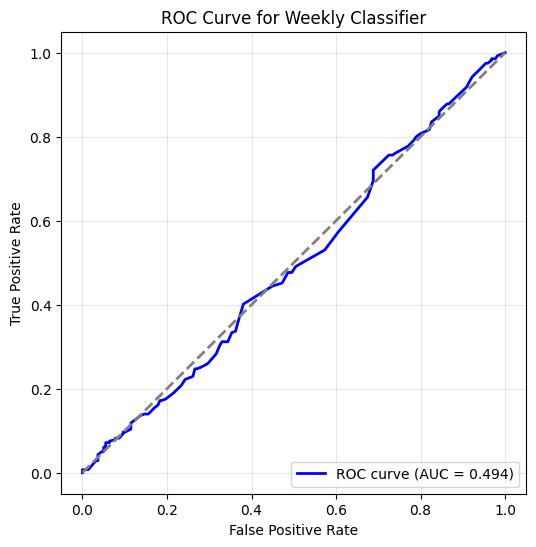

Test ROC AUC: 0.4940975304988327


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Fit the model on training set ---
clf.fit(X_train, y_train)

# --- Predict probabilities on the test set ---
y_proba = clf.predict_proba(X_test)[:, 1]   # probability of class 1 (good week)

# --- ROC curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Weekly Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("Test ROC AUC:", roc_auc)


In [26]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# probabilities from your fitted model
y_proba = clf.predict_proba(X_test)[:, 1]

# choose thresholds to inspect
thresholds = [0.1,0.3, 0.5, 0.7,0.9]

metrics = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    metrics.append((t, acc, prec, rec, f1))

# Display nicely
import pandas as pd
metrics_df = pd.DataFrame(metrics, columns=['Threshold','Accuracy','Precision','Recall','F1'])
print(metrics_df)


   Threshold  Accuracy  Precision    Recall        F1
0        0.1  0.561368   0.561368  1.000000  0.719072
1        0.3  0.476861   0.553073  0.354839  0.432314
2        0.5  0.452716   0.612903  0.068100  0.122581
3        0.7  0.438632   0.000000  0.000000  0.000000
4        0.9  0.438632   0.000000  0.000000  0.000000


In [27]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve

# Probabilities from the model
y_proba = clf.predict_proba(X_test)[:, 1]

# Generate thresholds from ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

best_thresh = 0
best_f1 = -1
best_metrics = {}

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
        best_metrics = {
            'Threshold': t,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        }

print("Optimal threshold for best F1_scores:", best_thresh)
print("Metrics at optimal threshold for best F1:", best_metrics)


Optimal threshold for best F1_scores: 0.17
Metrics at optimal threshold for best F1: {'Threshold': 0.17, 'Accuracy': 0.5653923541247485, 'Precision': 0.5641547861507128, 'Recall': 0.992831541218638, 'F1': 0.7194805194805195}


In [28]:
weekly_full.to_csv("weekly_features.csv", index=True)

# Random Forest Classifier Results

## Threshold Analysis
| Threshold | Accuracy | Precision | Recall | F1  |
|-----------|----------|-----------|--------|-----|
| 0.1       | 0.561    | 0.561     | 1.000  | 0.719 |
| 0.3       | 0.477    | 0.553     | 0.355  | 0.432 |
| 0.5       | 0.453    | 0.613     | 0.068  | 0.123 |
| 0.7       | 0.439    | 0.000     | 0.000  | 0.000 |
| 0.9       | 0.439    | 0.000     | 0.000  | 0.000 |

**Interpretation:**  
- At the default threshold (0.5), the model fails to detect positives (good weeks).  
- Only at very low thresholds (0.1–0.2) does recall become high, but this is due to predicting nearly everything as positive.

---

## ROC Curve
- **AUC = 0.494** → essentially random.  
- The ROC curve stays close to the diagonal, indicating no separation between good and bad weeks.

---

## Optimal Threshold
- **Best threshold (by F1):** 0.17  
- **Metrics at threshold 0.17:**  
  - Accuracy: 0.566  
  - Precision: 0.564  
  - Recall: 0.993  
  - F1-score: 0.719  

**Interpretation:**  
At threshold ≈0.17, the model achieves high recall by predicting almost every week as “good.” This yields a deceptively high F1 but does not reflect real predictive ability.

---

## Conclusion
- Random Forest does not capture meaningful signal from the features (`buy_tue_open`, `Mon_Volume`, `PrevFri_Open`).  
- Performance hovers near random guessing (AUC ≈ 0.5).  
- Threshold tuning can adjust recall/precision trade-offs, but does not overcome the lack of underlying predictive power.
